In [69]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata
data=np.loadtxt('u_burger.txt', skiprows=8)


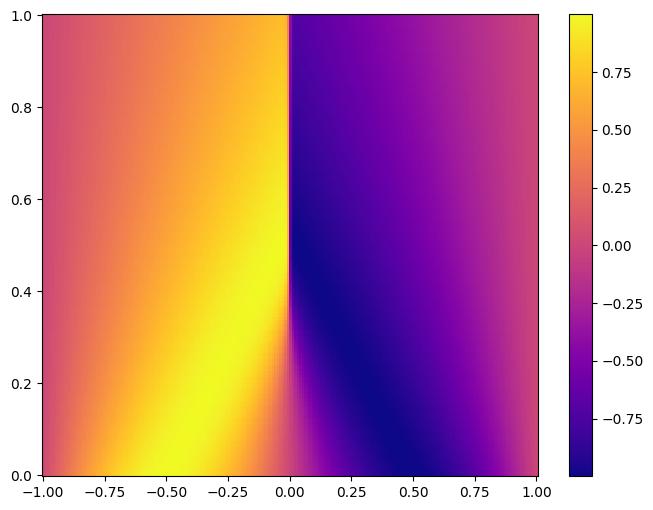

In [70]:
x_data=data[:, 0]
y_data=data[:, 1]
u_data=data[:, 2]
min_X=np.min(x_data)
max_X=np.max(x_data)
min_Y=np.min(y_data)
max_Y=np.max(y_data)
min_U=np.min(u_data)
max_U=np.max(u_data)
x=np.linspace(min_X, max_X, 200)
y=np.linspace(min_Y, max_Y, 200)
u=np.linspace(min_U, max_U, 200)
grid_x, grid_y = np.meshgrid(x,y)
grid_z = griddata((x_data, y_data), u_data, (grid_x, grid_y), method='nearest')
plt.figure(figsize=(8, 6))
mesh = plt.pcolor(grid_x, grid_y, grid_z, cmap='plasma')
plt.colorbar()
plt.show()

In [71]:
class PINNModel(nn.Module):
  def __init__(self,
              input_size = 1,
              nnodes = 30,
              output_size = 1,
              nhlayers = 20,
              activation=nn.Tanh(),
              ):
                super().__init__()
                self.activation = activation
                self.nhlayers = nhlayers
                self.nnodes = nnodes
                self.dense0 = nn.Linear(input_size, nnodes)
                self.hidden_layers = nn.ModuleList([
                nn.Linear(nnodes, nnodes) for _ in range(nhlayers)
                ])
                self.output_layer = nn.Linear(nnodes, 1)

  def forward(self, x):
    if x.dtype == torch.float64:
      x = x.float()

    x = self.activation(self.dense0(x))

    for layer in self.hidden_layers:
      x = self.activation(layer(x))

    x=self.output_layer(x)
    x=self.activation(x)

    return x

In [72]:
model = PINNModel(input_size=1)

x_test = torch.randn(35, 1)
y_test = model(x_test)
print("\nУспешно! Выход:", y.shape)


Успешно! Выход: (200,)


In [73]:
def prepare_data(x_np, y_np, u_np, device='cpu'):
    # Делаем всё плоским
    x_flat = np.array(x_np).flatten()
    y_flat = np.array(y_np).flatten()
    u_flat = np.array(u_np).flatten()

    # Собираем вход: (N, 2)
    xy = np.stack([x_flat, y_flat], axis=1)      # форма (N, 2)

    # Целевые значения: (N, 1)
    u = u_flat.reshape(-1, 1)

    # Переводим в тензоры
    xy_tensor = torch.from_numpy(xy).float().to(device)
    u_tensor  = torch.from_numpy(u).float().to(device)

    return xy_tensor, u_tensor


if torch.is_tensor(x):
    x = x.detach().cpu().numpy()
if torch.is_tensor(y):
    y = y.detach().cpu().numpy()
if torch.is_tensor(u):
    u = u.detach().cpu().numpy()

xy, u = prepare_data(x_data, y_data, u_data)

print(xy.shape)   # должно быть (N, 2)
print(u.shape)    # должно быть (N, 1)

torch.Size([181621, 2])
torch.Size([181621, 1])


In [74]:
hist_loss =[]
def copyLoss(model, trp):
    # Предсказание сети
    u_pred = model(trp.xy)

    # Истинные значения
    u_true = trp.u

    # Среднеквадратичная ошибка (MSE)

    return torch.mean((u_pred - u_true)**2)

class TrainParams:
    def __init__(self, xy, u, numEpoch=1000):
        self.xy = xy              # тензор формы (N, 2)
        self.u = u              # тензор формы (N, 1)
        self.numEpoch = numEpoch

def train(model, opt, trp: TrainParams):
  pbar = tqdm.tqdm(range(trp.numEpoch), desc='Training Progress')
  for step in pbar:
    def closure(): # вычисление одного шага алгоритма оптимизации
# Обнуление градиентов (по умолчанию – градиенты накавливаются)
      opt.zero_grad()
      loss = copyLoss(model, trp)
#градиенты функции потерь по всем параметрам модели
      loss.backward()
      return loss
#Оптимизатор вызывает closure, получает градиенты и изменяет параметры модели
    current_loss = opt.step(closure).item()
    hist_loss.append(current_loss)
    if step % 2 == 0:
      pbar.set_description("Step: %d | Loss: %.10f" %
(step, current_loss))
#сохранение весов модели
  torch.save(model.state_dict(), 'pinn_model')
  return 0

In [87]:
trp = TrainParams(xy=xy, u=u, numEpoch=15000)

# Модель и оптимизатор
model = PINNModel(input_size=2)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

hist_loss = []

# Обучение
train(model, opt, trp)

Step: 14998 | Loss: 0.0000669209: 100%|██████████| 15000/15000 [6:31:39<00:00,  1.57s/it]


0

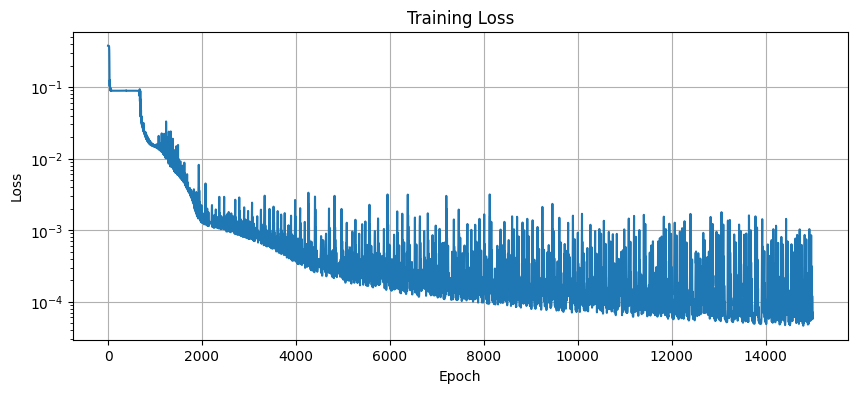

MSE = 6.968504e-05


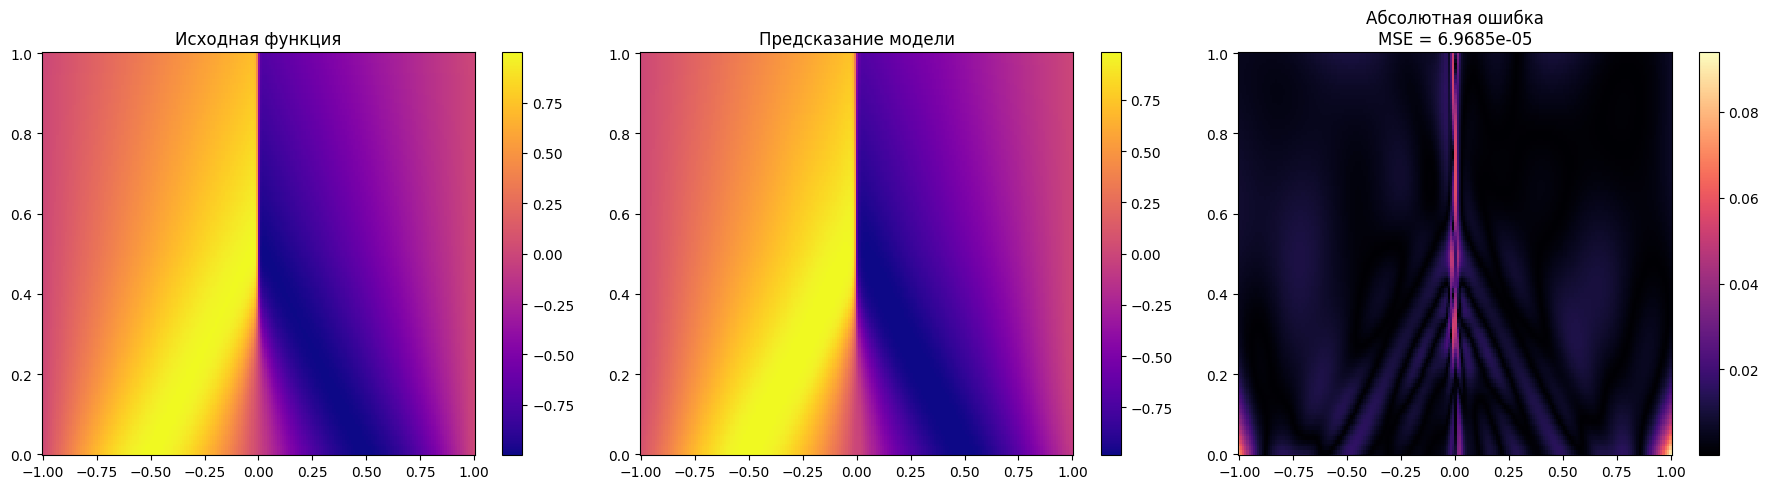

In [88]:


# ======================
# 1. График обучения
# ======================
plt.figure(figsize=(10, 4))
plt.plot(hist_loss)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# ======================
# 2. Предсказание
# ======================
model.eval()
with torch.no_grad():
    u_pred = model(xy)

x_data_np = xy[:, 0].cpu().numpy()
y_data_np = xy[:, 1].cpu().numpy()
u_true_np = u.cpu().numpy().flatten()
u_pred_np = u_pred.cpu().numpy().flatten()

mse = np.mean((u_true_np - u_pred_np)**2)
print(f"MSE = {mse:.6e}")

# ======================
# 3. Создаём сетку ТОЧНО ТАК ЖЕ, как в вашем исходном коде
# ======================
# Важно: используем оригинальные x и y, которыми вы делали meshgrid раньше
grid_x, grid_y = np.meshgrid(x, y)          # ← те самые x и y из исходного графика

grid_z_true = grid_z

grid_z_pred = griddata((x_data_np, y_data_np), u_pred_np,
                       (grid_x, grid_y), method='nearest')

# ======================
# 4. Рисуем
# ======================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mesh0 = axes[0].pcolor(grid_x, grid_y, grid_z_true, cmap='plasma')
axes[0].set_title('Исходная функция')
plt.colorbar(mesh0, ax=axes[0])

mesh1 = axes[1].pcolor(grid_x, grid_y, grid_z_pred, cmap='plasma')
axes[1].set_title('Предсказание модели')
plt.colorbar(mesh1, ax=axes[1])

error_grid = np.abs(grid_z_true - grid_z_pred)
mesh2 = axes[2].pcolor(grid_x, grid_y, error_grid, cmap='magma')
axes[2].set_title(f'Абсолютная ошибка\nMSE = {mse:.4e}')
plt.colorbar(mesh2, ax=axes[2])

plt.tight_layout()
plt.show()